In [1]:
import json
import os
import sys
import random

root_dir = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), '.'))
sys.path.append(root_dir)

from constants import *

import numpy as np

# import my_plot
from my_plot import *

from file_reader import *

import json


folder= "../../../../../应用/Overleaf/" + "Benchmarking RL Spatial Index"


In [2]:

# Open and read the JSON file
with open("best_models_grid_search.json", "r") as json_file:
    output_dict = json.load(json_file)

# Print the contents (optional)
# for dataset, indices in output_dict.items():
#     print(f"Dataset: {dataset}")
#     for index, model in indices.items():
#         print(f"  Index: {index}, Best Model: {model}")

### Parameters

In [3]:
# baselines = ['bmtree', 'kdtree', 'ketree_greddy', 'qdtree', 'r_star_tree', 'rankspace_zorder', 'rlrtree', 'rtree', 'zorder']
build_result_path = "../result/libspatialindex/HDD/4K/{name}/build/"
point_result_path = "../result/libspatialindex/HDD/4K/{name}/point/"
range_result_path = "../result/libspatialindex/HDD/4K/{name}/range/"
knn_result_path = "../result/libspatialindex/HDD/4K/{name}/knn/"
insert_result_path = "../result/libspatialindex/HDD/4K/{name}/insert/"
insert_point_result_path = "../result/libspatialindex/HDD/4K/{name}/insert_point/"

baseline_suffix = {'bmtree':'_bits_32_depth_10_sample_10000', 
                   'kdtree':'',
                   'platon':'',
                   'zmindex':'',
                   'waffle':'',
                   'kdtree_greedy':'',
                   'qdtree':'_episode_10_sampling_ratio_0.0001_action_space_200',
                   'r_star_tree':'_rstar',
                   'rankspace_zorder':'_bits_32',
                   'rlrtree':'_rlrtree_epoch_10_sample_10000',
                   'rtree':'_quadratic',
                   'zorder':'_bits_32'}


data_names = ["us_100000000", "india_100000000", "australia_100000000", "data_100000000_2_uniform_1", "data_100000000_2_normal_1", "data_100000000_2_skewed_4"]
data_names_write = ["us_10000000", "india_10000000", "australia_10000000", "data_10000000_2_uniform_1", "data_10000000_2_normal_1", "data_10000000_2_skewed_4"]
display_data_names = ["US", "INDIA", "AUS", "UNI", "NORM",  "SKEW"]

real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"

special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']
baselines = ['rtree', 'r_star_tree',  'kdtree', 'kdtree_greedy','zorder', 'rankspace_zorder']
baselines = ['rtree', 'r_star_tree', 'rlrtree', 'kdtree', 'kdtree_greedy', 'qdtree', 'zorder', 'rankspace_zorder', 'bmtree']
baselines = ['rtree', 'r_star_tree', 'platon', 'rlrtree', 'kdtree', 'kdtree_greedy', 'waffle', 'qdtree', 'zorder', 'rankspace_zorder', 'zmindex', 'bmtree']
display_baselines = ['RT', 'RST', 'KD', 'KDG','ZR', 'ZRR']
display_baselines = ['RT', 'RST', 'RLR', 'KD', 'KDG', 'QD','ZR', 'ZRR', 'BMT']
display_baselines = ['R-tree', 'R*-tree', 'RLR-tree', 'Kd-tree', 'GKd-tree', 'Qd-tree','ZR-tree', 'ZRR-tree', 'BM-tree']
display_baselines = ['R-tree', 'R*-tree', 'PLATON', 'RLR-tree', 'Kd-tree', 'Waffle', 'GKd-tree', 'Qd-tree','ZR-tree', 'ZRR-tree', 'ZM-index', 'BM-tree']

In [4]:
data_names = ["us_100000000"]
data_names = ["us_100000000", "india_100000000", "australia_100000000", "data_100000000_2_uniform_1", "data_100000000_2_normal_1", "data_100000000_2_skewed_4"]
data_names_write = ["us_10000000"]
display_data_names = ["US"]
real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"

data_name = "us_100000000"
query_ranges=[0.0001, 0.0005, 0.001, 0.005, 0.01]

real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_{r1}x{r2}"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_{r1}x{r2}"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"

# baselines = ['rlrtree', 'qdtree',  'bmtree']
# display_baselines = ['RLR-tree', 'Qd-tree', 'BM-tree']


In [5]:
disk_types = ["HDD", "SSD"]

query_types = ["Index Building", "Point Query", "Range Query", "$k$NN Query"]

build_result_path = "../result/libspatialindex/{disk_type}/4K/{name}/build/"
point_result_path = "../result/libspatialindex/{disk_type}/4K/{name}/point/"
range_result_path = "../result/libspatialindex/{disk_type}/4K/{name}/range/"
knn_result_path = "../result/libspatialindex/{disk_type}/4K/{name}/knn/"

# baseline_suffix = {'bmtree':'_bits_32_depth_10_sample_10000', 
#                    'kdtree':'',
#                    'kdtree_greedy':'',
#                    'qdtree':'_episode_10_sampling_ratio_0.0001_action_space_200',
#                    'r_star_tree':'_rstar',
#                    'rankspace_zorder':'_bits_32',
#                    'rlrtree':'_rlrtree_epoch_10_sample_10000',
#                    'rtree':'_quadratic',
#                    'zorder':'_bits_32'}

data_names = ["us_100000000"]
display_data_names = ["US"]
real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"
special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']
# baselines = ['rtree', 'r_star_tree', 'rlrtree', 'kdtree', 'kdtree_greedy', 'qdtree', 'zorder', 'rankspace_zorder', 'bmtree']
# display_baselines = ['R-tree', 'R*-tree', 'RLR-tree', 'Kd-tree', 'GKd-tree', 'Qd-tree','ZR-tree', 'ZRR-tree', 'BM-tree']

real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"

real_point_name = "{data_name}_point_200000_2_uniform_1"
synthetic_point_name = "point_200000_{data_name}_2_uniform_1"
point_result_name_pattern = "{data_name}{default_range_name}_{point_name}{suffix}.txt"
special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']
knn_result_name_pattern = "{data_name}{default_range_name}_{knn_name}_k_{k}{suffix}.txt"
real_knn_name = "{data_name}_knn_1000_2_uniform_1"
synthetic_knn_name = "knn_1000_2_uniform_1"


synthetic_insert_point_name = "insert_point_10000000_{data_name}_2_uniform_1"
insert_point_result_name_pattern = "{data_name}{default_range_name}_{insert_point_name}_2_18{suffix}.txt"
real_insert_point_name = "{data_name}_insert_point_10000000_2_uniform_1"
synthetic_insert_name = "insert_10000000_2_uniform_1"
real_insert_name = "{data_name}_insert_10000000_2_uniform_1"
insert_result_name_pattern = "{data_name}{default_range_name}_{insert_name}{suffix}.txt"


In [6]:
data_name = "us_100000000"
k=25
point_query = []
range_query = []
knn_query = []
build_time = []

for baseline in baselines:
    point_query_sampled = []
    range_query_sampled = []
    knn_query_sampled = []
    build_time_sampled = []
    for disk_type in disk_types:    

        suffix = baseline_suffix[baseline]

        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            point_name = synthetic_point_name.format(data_name=data_name)
            knn_name = synthetic_knn_name
            
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            point_name = real_point_name.format(data_name=data_name)
            knn_name = real_knn_name.format(data_name=data_name)

        # default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
        range_name=real_range_name_pattern.format(data_name=data_name)
        build_result_name = build_result_name_pattern.format(
            data_name=data_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix
        )

        # print(build_result_name)
        res = os.path.join(build_result_path.format(name=baseline,disk_type=disk_type), build_result_name)
        tree_property = parse_rtree_properties(res)
        # build_time_sampled.append(tree_property.ElapsedLearnTime / 1e9)
        build_time_sampled.append(tree_property.ElapsedTime / 1e9)
        
        point_result_name = point_result_name_pattern.format(
            data_name=data_name,
            point_name=point_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix
        )
        
        res = os.path.join(point_result_path.format(name=baseline,disk_type=disk_type), point_result_name)
        tree_property = parse_rtree_properties(res)
        point_query_sampled.append(tree_property.QueryMean / 1e3)


        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=range_name,
            suffix=suffix
        )
        # print(range_result_name)

        res = os.path.join(range_result_path.format(name=baseline,disk_type=disk_type), range_result_name)
        tree_property = parse_rtree_properties(res)
        range_query_sampled.append(tree_property.QueryMean / 1e3)

        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name,
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline,disk_type=disk_type), knn_result_name)
        tree_property = parse_rtree_properties(res)
        knn_query_sampled.append(tree_property.QueryMean / 1e3)

        # print(build_result_path.format(name=baseline,disk_type=disk_type), build_result_name)
        # print(point_result_path.format(name=baseline,disk_type=disk_type),point_result_name)
        # print(range_result_path.format(name=baseline,disk_type=disk_type), range_result_name)
        # print(knn_result_path.format(name=baseline,disk_type=disk_type), knn_result_name)
    #     break
    # break

    point_query.append(point_query_sampled)
    range_query.append(range_query_sampled)
    knn_query.append(knn_query_sampled)
    build_time.append(build_time_sampled)
    


print(point_query)
# print(range_query)
# print(knn_query)
# print(build_time)

[[252.981183835, 209.514627965], [68.39498151500001, 58.131101900000004], [0.0, 0.0], [515.64004684, 168.508468045], [750.58698992, 37.357784795], [4405.646971625, 42.52414486999999], [0.0, 0.0], [50.564990885, 37.500255134999996], [133.09802888, 110.22995365999999], [96.37185978, 89.01221596], [0.0, 0.0], [106.88838000999999, 424.32672634]]


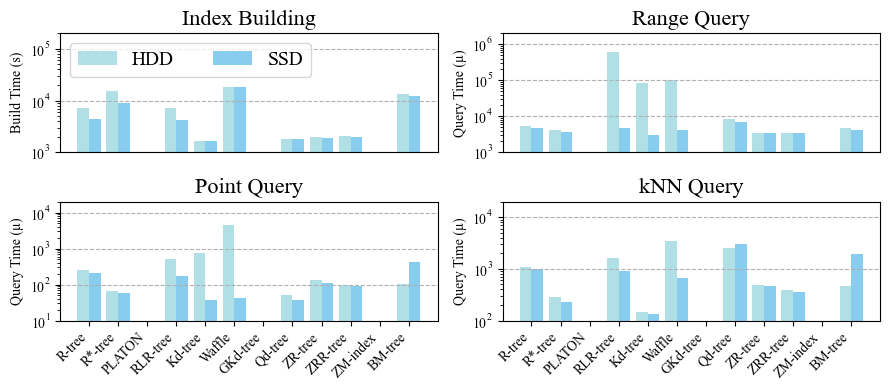

In [7]:
# import matplotlib.pyplot as plt
# import numpy as np
# colors = ['#A9A9F5', '#FFD700', '#88CCEE', '#FFCC99', '#FFA07A', '#FF6F61', '#B0E0E6', '#2CA02C', '#AA4499']

all_data = [build_time, range_query, point_query, knn_query]
query_types = ['Index Building', 'Range Query', 'Point Query', 'kNN Query']
bottoms = [1e3, 1*1e3, 1e1, 1e2]
tops = [2*1e5, 2*1e6, 2*1e4, 2*1e4]

# display_baselines = [f'Baseline {i+1}' for i in range(9)]  #

group_width = 0.8  
individual_bar_width = group_width / 2  
offset = individual_bar_width / 2  

fig, axes = plt.subplots(2, 2, figsize=(9, 4), sharey=False)

for i, (ax, query_type, data) in enumerate(zip(axes.flat, query_types, all_data)):
    x = np.arange(len(display_baselines)) 
    
    hdd_values = [row[0] for row in data] 
    ssd_values = [row[1] for row in data] 
    
    ax.bar(x - offset, hdd_values, individual_bar_width, label='HDD', color=colors[0], alpha=1.0) 
    ax.bar(x + offset, ssd_values, individual_bar_width, label='SSD', color=colors[1], alpha=1.0) 


    ax.set_title(f'{query_type}', fontsize=16)
    if i > 1:
        ax.set_xticks(x)  
        ax.set_xticklabels(display_baselines, rotation=45, ha='right') 
    else:
        ax.set_xticks([])  
        

    if i == 0:
        ax.set_ylabel('Build Time (s)') 
    else:
        ax.set_ylabel('Query Time (µ)') 

    ax.set_ylim(bottom=bottoms[i])
    ax.set_ylim(top=tops[i])
    
    ax.set_yscale('log')
    ax.grid(True, axis='y', linestyle='--', alpha=1.0)

axes[0, 0].legend(loc='upper left', fontsize=14, ncol=2)  

output_file_paths = [folder + "/exp_sigmod/hdd_vs_ssd.pdf", "../figs/exp_sigmod/hdd_vs_ssd.png"]

plt.tight_layout()

if output_file_paths:
    for output_file_path in output_file_paths:
        if output_file_path.endswith(".pdf"):
            plt.savefig(output_file_path, format='pdf', bbox_inches='tight')
        if output_file_path.endswith(".png"):
            plt.savefig(output_file_path, format='png', bbox_inches='tight')


plt.show()

In [8]:

data_names = ["us_100000000", "india_100000000", "australia_100000000", "data_100000000_2_uniform_1", "data_100000000_2_normal_1", "data_100000000_2_skewed_4"]
data_names_write = ["us_10000000", "india_10000000", "australia_10000000", "data_10000000_2_uniform_1", "data_10000000_2_normal_1", "data_10000000_2_skewed_4"]
display_data_names = ["US", "INDIA", "AUS", "UNI", "NORM", "SKEW"]

real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"

real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"

real_point_name = "{data_name}_point_200000_2_uniform_1"
synthetic_point_name = "point_200000_{data_name}_2_uniform_1"
point_result_name_pattern = "{data_name}{default_range_name}_{point_name}{suffix}.txt"
special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']

insert_point_result_name_pattern = "{data_name}{default_range_name}_{insert_point_name}_10_10{suffix}.txt"
synthetic_insert_name = "insert_10000000_2_uniform_1"
real_insert_name = "{data_name}_insert_10000000_2_uniform_1"
insert_result_name_pattern = "{data_name}{default_range_name}_{insert_name}{suffix}.txt"

spider_build_time = []
spider_index_size = []
spider_point_query = []
spider_range_query = []
spider_knn_query = []
spider_balanced = []
spider_write_only = []

for data_name, data_name_write in zip(data_names, data_names_write):

    dict_spider_build_time = {}
    dict_spider_index_size = {}
    dict_spider_point_query = {}
    dict_spider_range_query = {}
    dict_spider_knn_query = {}
    dict_spider_balanced = {}
    dict_spider_write_only = {}

    for baseline, display_baseline in zip(baselines, display_baselines):
        suffix = baseline_suffix[baseline]
        
        default_range_name = ''
        default_range_name_write = ''
        if baseline in special_baselines:
            if data_name.startswith("data"):
                default_range_name = synthetic_default_range_name_pattern
                default_range_name_write = default_range_name
            else:
                default_range_name = real_default_range_name_pattern.format(data_name=data_name)
                default_range_name_write = real_default_range_name_pattern.format(data_name=data_name_write)
        
        build_result_name = build_result_name_pattern.format(
            data_name=data_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(build_result_path.format(name=baseline, disk_type="HDD"), build_result_name)

        tree_property = parse_rtree_properties(res)

        dict_spider_build_time[display_baseline] = tree_property.ElapsedTime
        dict_spider_index_size[display_baseline] = tree_property.TreeDatSize + tree_property.TreeIdxSize

    # for baseline, display_baseline in zip(baselines, display_baselines):
    #     suffix = baseline_suffix[baseline]
        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            point_name = synthetic_point_name.format(data_name=data_name)
            range_name = synthetic_range_name_pattern
            knn_name = synthetic_knn_name

            insert_name = synthetic_insert_name
            insert_point_name = synthetic_insert_point_name.format(data_name=data_name_write) 
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            point_name = real_point_name.format(data_name=data_name)
            range_name=real_range_name_pattern.format(data_name=data_name)
            knn_name = real_knn_name.format(data_name=data_name)
            
            insert_name=real_insert_name.format(data_name=data_name_write) 
            insert_point_name=real_insert_point_name.format(data_name=data_name_write) 
            
        point_result_name = point_result_name_pattern.format(
            data_name=data_name,
            point_name=point_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(point_result_path.format(name=baseline, disk_type="HDD"), point_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_point_query[display_baseline] = tree_property.QueryMean

        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=range_name,
            suffix=suffix
        )
        res = os.path.join(range_result_path.format(name=baseline, disk_type="HDD"), range_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_range_query[display_baseline] = tree_property.QueryMean

        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name,
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline, disk_type="HDD"), knn_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_knn_query[display_baseline] = tree_property.QueryMean

        insert_result_name = insert_result_name_pattern.format(
            data_name=data_name_write,
            insert_name=insert_name,
            default_range_name=default_range_name_write,
            suffix=suffix
        )
        res = os.path.join(insert_result_path.format(name=baseline), insert_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_write_only[display_baseline] = tree_property.InsertMean
        
        insert_point_result_name = insert_point_result_name_pattern.format(
            data_name=data_name_write,
            insert_point_name=insert_point_name,
            default_range_name=default_range_name_write,
            suffix=suffix
        )
        res = os.path.join(insert_point_result_path.format(name=baseline), insert_point_result_name)
        tree_property = parse_rtree_properties(res)
        # dict_spider_balanced[display_baseline] = tree_property.QueryMean
        dict_spider_balanced[display_baseline] = tree_property.InsertMean    

    ranked_spider_build_time = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_build_time.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_index_size = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_index_size.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_point_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_point_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_range_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_range_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_knn_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_knn_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_balanced = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_balanced.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_write_only = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_write_only.items(), key=lambda item: item[1], reverse=True), 1)
    }

    spider_build_time.append(ranked_spider_build_time)
    spider_index_size.append(ranked_spider_index_size)
    spider_point_query.append(ranked_spider_point_query)
    spider_range_query.append(ranked_spider_range_query)
    spider_knn_query.append(ranked_spider_knn_query)
    spider_balanced.append(ranked_spider_balanced)
    spider_write_only.append(ranked_spider_write_only)

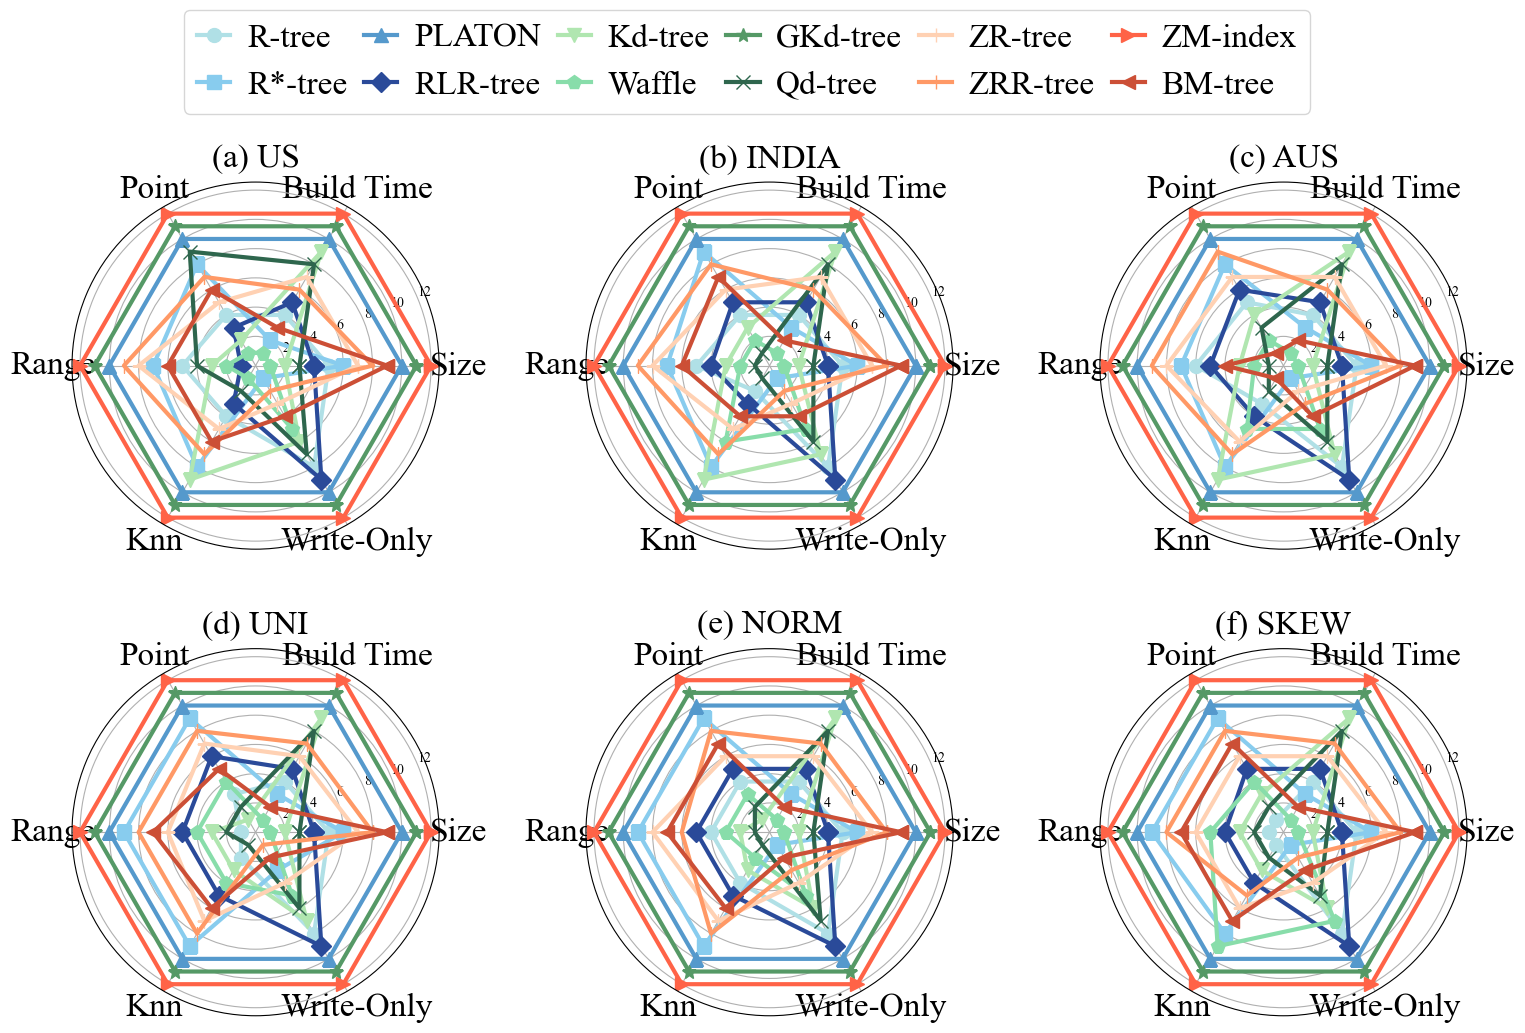

In [9]:
# import matplotlib.pyplot as plt
# import numpy as np


label_size = 24
legend_size = 20
categories = ['Size', 'Build Time', 'Point', 'Range', 'Knn', 'Write-Only']
letters = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
num_vars = len(categories)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Define the number of subplots (2 rows, 3 columns for 6 subplots)
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 12), subplot_kw=dict(polar=True))

# Flatten the array of axes for easier iteration
axs = axs.flatten()

markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'x', '+', '|', '>', '<']

linestyles = [None, None, None,'-', None, None, None,'--', None, None, None,'-.']

for j, ax in enumerate(axs):

    # baseline = []
    for i, display_baseline in enumerate(display_baselines):

        baseline = [
        spider_index_size[j][display_baseline],
        spider_build_time[j][display_baseline],
        spider_point_query[j][display_baseline],
        spider_range_query[j][display_baseline],
        spider_knn_query[j][display_baseline],
        # spider_balanced[j][display_baseline],
        spider_write_only[j][display_baseline]]
        # baseline = [random.randint(1, 9) for _ in range(len(categories))]
        baseline += baseline[:1]
        ax.plot(angles, baseline, color=colors[i], linewidth=3, marker=markers[i], markersize=10, label=display_baseline)


    # Fill in the labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=label_size)
    ax.set_title(letters[j] + " " + display_data_names[j], fontsize=label_size)

#     if j == 1:
#         # Add a legend for each subplot
#         ax.legend(loc='upper center', fontsize=legend_size, bbox_to_anchor=(0.5, 1.15), ncol=9)  # Adjust the position and columns

fig.legend(display_baselines, loc='upper center', fontsize=label_size, ncol=6, 
           handlelength=1,           
                handletextpad=0.5,   
                columnspacing=0.5,
           bbox_to_anchor=(0.5, 1.0))

        # borderaxespad=0.5,  # Border padding
        # handletextpad=0.5,  # Padding between legend marker and text
        # labelspacing=0.3    # Vertical space between legend entries

# Adjust layout to prevent overlap
# plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make room for the legend

# plt.tight_layout(pad=1.0, w_pad=2.0, h_pad=0.0)

# pad: Padding between the figure edge and the edges of subplots.
# w_pad: Padding (width) between subplots.
# h_pad: Padding (height) between subplots.

# left, right, top, bottom: Control the margins around the entire figure.
# wspace: Controls the width space between the subplots.
# hspace: Controls the height space between the subplots.

plt.subplots_adjust(wspace=0.4, hspace=0.02)


# Adjust layout to prevent overlap
# plt.tight_layout()

plt.savefig(folder + "/exp_sigmod/spider.pdf", format='pdf', bbox_inches='tight')
plt.savefig("../figs/exp_sigmod/spider.png", format='png', bbox_inches='tight')

# Show the entire figure with all subplots
plt.show()


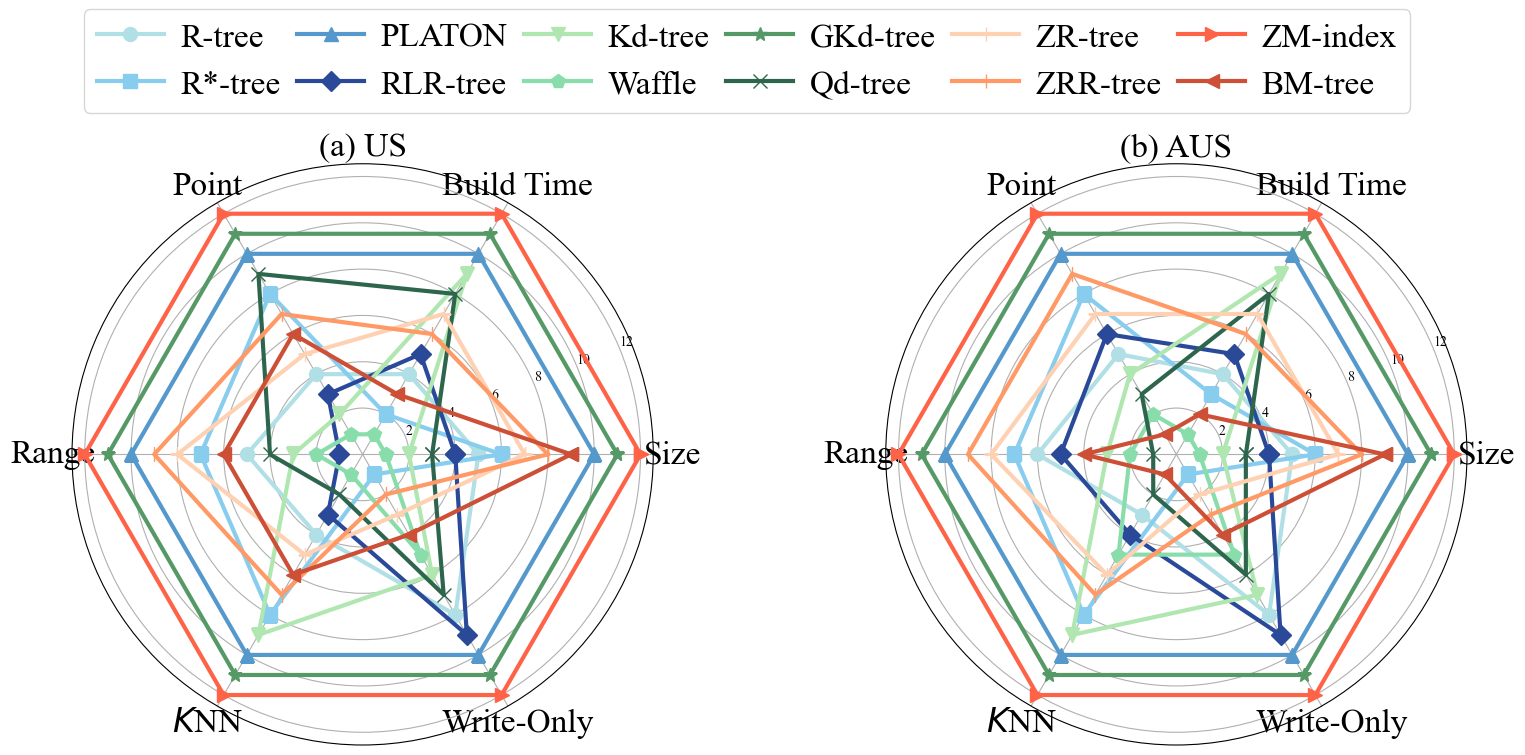

In [15]:
data_names = ["us_100000000", "australia_100000000"]
data_names_write = ["us_10000000", "australia_10000000"]
display_data_names = ["US", "AUS"]


spider_build_time = []
spider_index_size = []
spider_point_query = []
spider_range_query = []
spider_knn_query = []
spider_balanced = []
spider_write_only = []

for data_name, data_name_write in zip(data_names, data_names_write):

    dict_spider_build_time = {}
    dict_spider_index_size = {}
    dict_spider_point_query = {}
    dict_spider_range_query = {}
    dict_spider_knn_query = {}
    dict_spider_balanced = {}
    dict_spider_write_only = {}

    for baseline, display_baseline in zip(baselines, display_baselines):
        suffix = baseline_suffix[baseline]
        
        default_range_name = ''
        default_range_name_write = ''
        if baseline in special_baselines:
            if data_name.startswith("data"):
                default_range_name = synthetic_default_range_name_pattern
                default_range_name_write = default_range_name
            else:
                default_range_name = real_default_range_name_pattern.format(data_name=data_name)
                default_range_name_write = real_default_range_name_pattern.format(data_name=data_name_write)
        
        build_result_name = build_result_name_pattern.format(
            data_name=data_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(build_result_path.format(name=baseline, disk_type="HDD"), build_result_name)

        tree_property = parse_rtree_properties(res)

        dict_spider_build_time[display_baseline] = tree_property.ElapsedTime
        dict_spider_index_size[display_baseline] = tree_property.TreeDatSize + tree_property.TreeIdxSize

    # for baseline, display_baseline in zip(baselines, display_baselines):
    #     suffix = baseline_suffix[baseline]
        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            point_name = synthetic_point_name.format(data_name=data_name)
            range_name = synthetic_range_name_pattern
            knn_name = synthetic_knn_name

            insert_name = synthetic_insert_name
            insert_point_name = synthetic_insert_point_name.format(data_name=data_name_write) 
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            point_name = real_point_name.format(data_name=data_name)
            range_name=real_range_name_pattern.format(data_name=data_name)
            knn_name = real_knn_name.format(data_name=data_name)
            
            insert_name=real_insert_name.format(data_name=data_name_write) 
            insert_point_name=real_insert_point_name.format(data_name=data_name_write) 
            
        point_result_name = point_result_name_pattern.format(
            data_name=data_name,
            point_name=point_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(point_result_path.format(name=baseline, disk_type="HDD"), point_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_point_query[display_baseline] = tree_property.QueryMean

        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=range_name,
            suffix=suffix
        )
        res = os.path.join(range_result_path.format(name=baseline, disk_type="HDD"), range_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_range_query[display_baseline] = tree_property.QueryMean

        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name,
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline, disk_type="HDD"), knn_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_knn_query[display_baseline] = tree_property.QueryMean

        insert_result_name = insert_result_name_pattern.format(
            data_name=data_name_write,
            insert_name=insert_name,
            default_range_name=default_range_name_write,
            suffix=suffix
        )
        res = os.path.join(insert_result_path.format(name=baseline), insert_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_write_only[display_baseline] = tree_property.InsertMean
        
        insert_point_result_name = insert_point_result_name_pattern.format(
            data_name=data_name_write,
            insert_point_name=insert_point_name,
            default_range_name=default_range_name_write,
            suffix=suffix
        )
        res = os.path.join(insert_point_result_path.format(name=baseline), insert_point_result_name)
        tree_property = parse_rtree_properties(res)
        # dict_spider_balanced[display_baseline] = tree_property.QueryMean
        dict_spider_balanced[display_baseline] = tree_property.InsertMean    

    ranked_spider_build_time = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_build_time.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_index_size = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_index_size.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_point_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_point_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_range_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_range_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_knn_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_knn_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_balanced = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_balanced.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_write_only = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_write_only.items(), key=lambda item: item[1], reverse=True), 1)
    }

    spider_build_time.append(ranked_spider_build_time)
    spider_index_size.append(ranked_spider_index_size)
    spider_point_query.append(ranked_spider_point_query)
    spider_range_query.append(ranked_spider_range_query)
    spider_knn_query.append(ranked_spider_knn_query)
    spider_balanced.append(ranked_spider_balanced)
    spider_write_only.append(ranked_spider_write_only)

import matplotlib.pyplot as plt
import numpy as np
import random

label_size = 24
legend_size = 20
categories = ['Size', 'Build Time', 'Point', 'Range', '$K$NN', 'Write-Only']
letters = ["(a)", "(b)"]
num_vars = len(categories)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Define the number of subplots (2 rows, 3 columns for 6 subplots)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18, 12), subplot_kw=dict(polar=True))

# Flatten the array of axes for easier iteration
axs = axs.flatten()

for j, ax in enumerate(axs):

    # baseline = []
    for i, display_baseline in enumerate(display_baselines):

        baseline = [
        spider_index_size[j][display_baseline],
        spider_build_time[j][display_baseline],
        spider_point_query[j][display_baseline],
        spider_range_query[j][display_baseline],
        spider_knn_query[j][display_baseline],
        # spider_balanced[j][display_baseline],
        spider_write_only[j][display_baseline]]
        # baseline = [random.randint(1, 9) for _ in range(len(categories))]
        baseline += baseline[:1]
        ax.plot(angles, baseline, color=colors[i], linewidth=3, marker=markers[i], markersize=10, label=display_baseline)


    # Fill in the labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=label_size)
    ax.set_title(letters[j] + " " + display_data_names[j], fontsize=label_size)

#     if j == 1:
#         # Add a legend for each subplot
#         ax.legend(loc='upper center', fontsize=legend_size, bbox_to_anchor=(0.5, 1.15), ncol=9)  # Adjust the position and columns


fig.legend(display_baselines, loc='upper center', fontsize=label_size, ncol=6, 
           handlelength=2,           
                handletextpad=0.5,   
                columnspacing=0.5,
           bbox_to_anchor=(0.5, 0.88))

plt.subplots_adjust(wspace=0.4, hspace=0.02)


# Adjust layout to prevent overlap
# plt.tight_layout()

plt.savefig(folder + "/exp_sigmod/spider.pdf", format='pdf', bbox_inches='tight')
plt.savefig("../figs/exp_sigmod/spider.png", format='png', bbox_inches='tight')

# Show the entire figure with all subplots
plt.show()
